
===== CSV LOADED =====
    dataset    modelo  n_classes      erro  n_classes_original
0  dry-bean       EMQ        7.0  0.034203                 NaN
1  dry-bean  EMQ_BCTS        7.0  0.033709                 NaN
2  dry-bean        CC        7.0  0.033714                 NaN
3  dry-bean       PCC        7.0  0.033501                 NaN
4  dry-bean        AC        7.0  0.031620                 NaN

===== MODELOS APÓS AGRUPAMENTO =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_BASE', 'MoSS_ISO_CALIBRATED', 'MoSS_RF_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_BASE', 'MoSS_ISO_CALIBRATED', 'MoSS_RF_CALIBRATED', 'PAC', 'PCC', 'PWK']

===== AVERAGE RANK =====
                 modelo  rank_dataset
0                   PCC      4.416667
1                   PWK      4.416667
2                    CC      6.895833
3                KDEyML      6.916667
4   MoSS_ISO_CALIBR

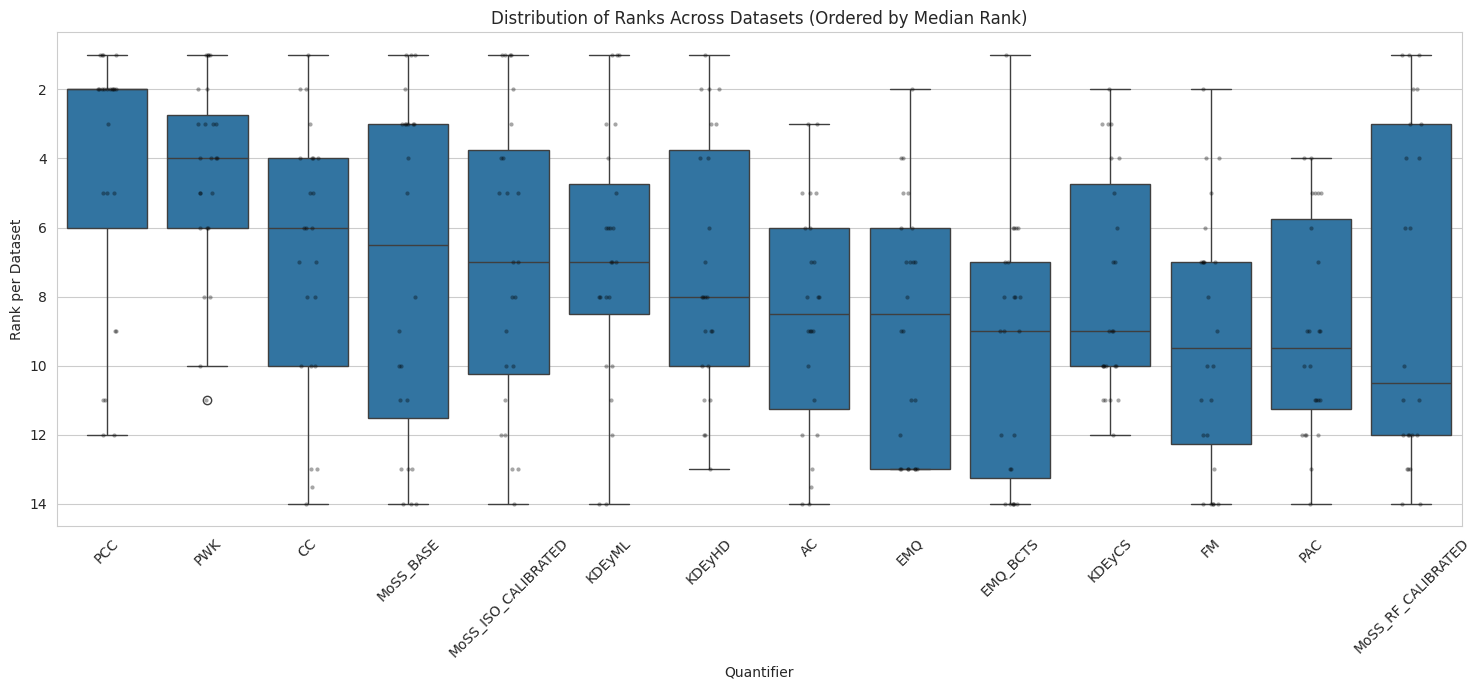

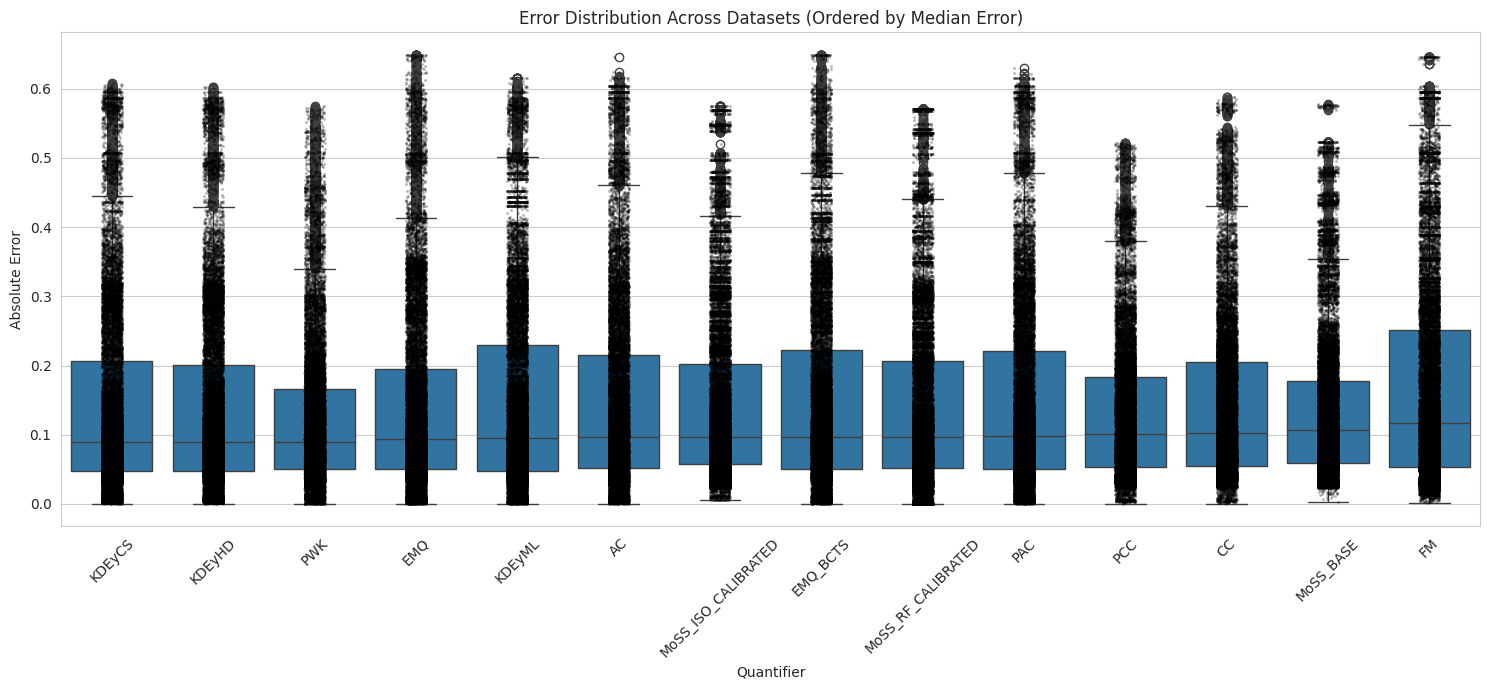


===== GLOBAL MEAN ERROR =====
                 modelo  mean_error
0                   PWK    0.123571
1                   PCC    0.131267
2             MoSS_BASE    0.139273
3                KDEyHD    0.139621
4    MoSS_RF_CALIBRATED    0.139937
5                KDEyCS    0.141634
6   MoSS_ISO_CALIBRATED    0.141762
7                    CC    0.142910
8                   EMQ    0.144195
9                   PAC    0.149278
10                   AC    0.149691
11               KDEyML    0.149710
12             EMQ_BCTS    0.152198
13                   FM    0.167230

===== GLOBAL MEDIAN ERROR =====
                 modelo  median_error
0                KDEyCS      0.089066
1                KDEyHD      0.089387
2                   PWK      0.090286
3                   EMQ      0.094372
4                KDEyML      0.094754
5                    AC      0.096669
6   MoSS_ISO_CALIBRATED      0.096678
7              EMQ_BCTS      0.096707
8    MoSS_RF_CALIBRATED      0.096761
9               

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    {
        r"MoSS_BASE_\d+": "MoSS_BASE",
        r"MoSS_ISO_CALIBRATED_\d+": "MoSS_ISO_CALIBRATED",
        r"MoSS_RF_CALIBRATED_\d+": "MoSS_RF_CALIBRATED",
    },
    regex=True
)

print("\n===== MODELOS APÓS AGRUPAMENTO =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# REMOVER MODELOS ESPECÍFICOS
# ============================================================

modelos_remover = [
    #"KDEyHD",
    #"KDEyCS",
    #"EMQ_BCTS",
    "ClusterQuant"
]

df = df[~df["modelo"].isin(modelos_remover)]

print("\n===== MODELOS RESTANTES =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

avg_rank.to_csv(
    "average_rank_filtered.csv",
    index=False
)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# SALVAR RESULTADOS
# ============================================================

#global_mean_error.to_csv(
#    "global_mean_error_filtered.csv",
#    index=False
#)

#global_median_error.to_csv(
#    "global_median_error_filtered.csv",
#    index=False
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")

In [6]:
# ============================================================
# TABELA COMPLETA DE RANKS POR DATASET
# ============================================================

rank_table = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="rank_dataset"
)

rank_table.to_csv(
    "rank_per_dataset_table.csv"
)

print("\n===== RANK TABLE =====")
print(rank_table)


===== RANK TABLE =====
modelo              AC    CC   EMQ  EMQ_BCTS    FM  KDEyCS  KDEyHD  KDEyML  \
dataset                                                                      
abalone           12.0   8.0   7.0       6.0  14.0     9.0    10.0    11.0   
academic-success   7.0  10.0   8.0       9.0  14.0     4.0     3.0     6.0   
chess             14.0   5.0  13.0      12.0   7.0    10.0     9.0     8.0   
cmc                9.0   4.0   5.0       6.0  14.0    11.0     8.0    10.0   
connect-4         12.0  13.0   9.0       8.0  14.0     3.0     4.0     7.0   
digits             8.0   5.0  13.0      14.0   4.0     9.0    10.0     6.0   
dry-bean           8.0   2.0   6.0       9.0  13.0    10.0    12.0     5.0   
hand_digits        5.0   4.0  12.0      13.0   7.0    10.0    11.0     6.0   
hcv               10.0   4.0   7.0      13.0  12.0     9.0     8.0    14.0   
image_seg          6.0   3.0  11.0      12.0   8.0     7.0     9.0     4.0   
isolet             9.0   7.0  13.0      


===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.034203
1  dry-bean  EMQ_BCTS                   7  0.033709
2  dry-bean        CC                   7  0.033714
3  dry-bean       PCC                   7  0.033501
4  dry-bean        AC                   7  0.031620

Total original datasets: 24

===== MODELOS APÓS AGRUPAMENTO =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'PAC', 'PCC', 'PWK', 'QMoSS', 'QMoSS_ISO', 'QMoSS_RF']

Total remaining models: 14
modelo
EMQ          24000
EMQ_BCTS     24000
CC           24000
PCC          24000
AC           24000
PAC          24000
FM           24000
KDEyML       24000
KDEyHD       24000
KDEyCS       24000
PWK          24000
QMoSS        24000
QMoSS_ISO    24000
QMoSS_RF     24000
Name: count, dtype: int64

===== MODELOS APÓS AGRUPAMENTO =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_BASE_10', 'MoSS_BASE_11', 'MoSS_BAS

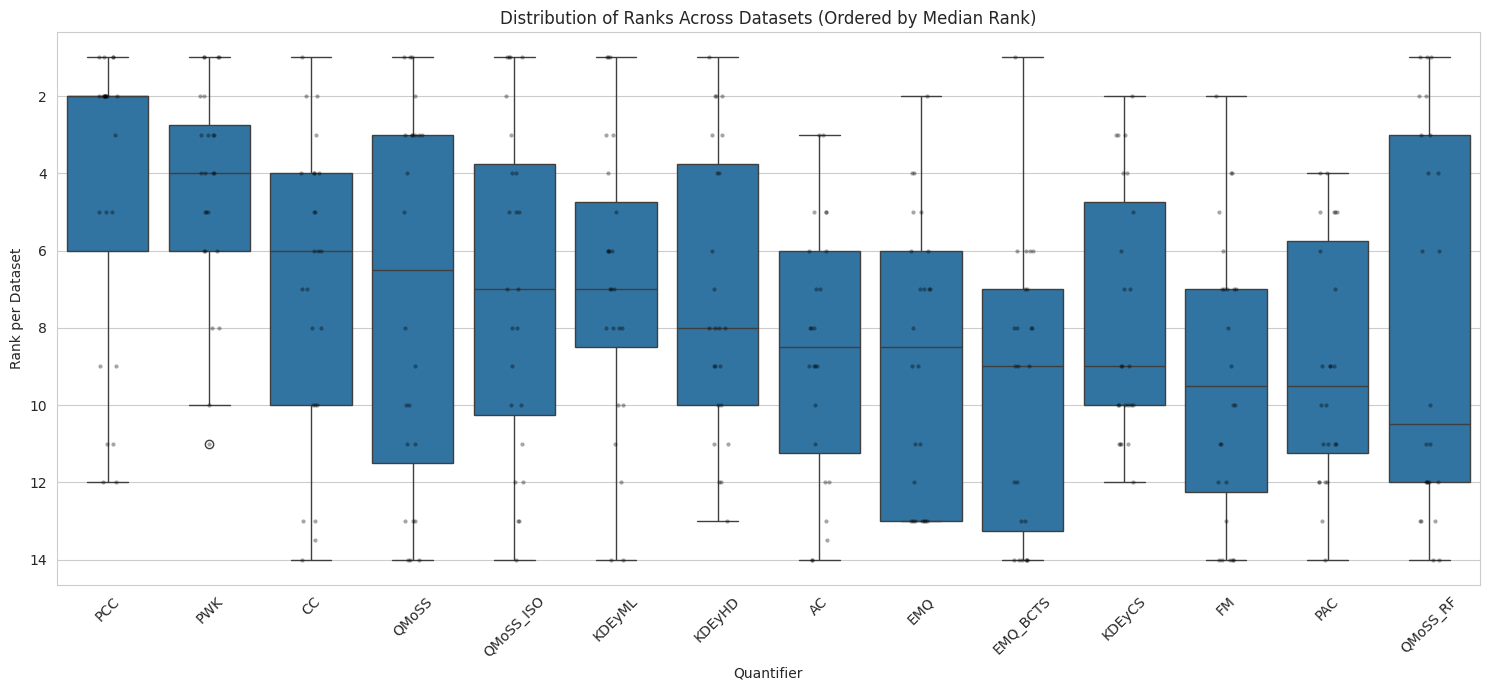

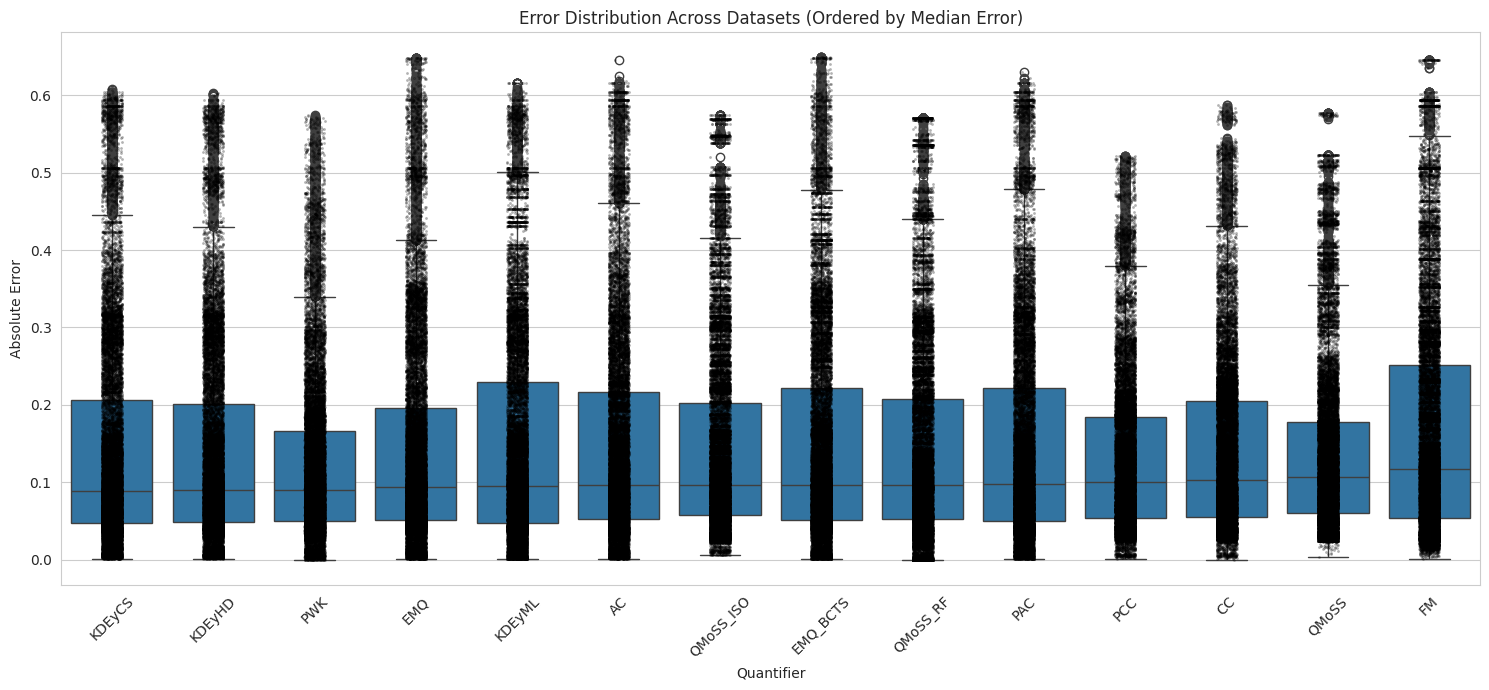


===== GLOBAL MEAN ERROR =====
       modelo  mean_error
0         PWK    0.123571
1         PCC    0.131267
2       QMoSS    0.139273
3      KDEyHD    0.139621
4    QMoSS_RF    0.139937
5      KDEyCS    0.141634
6   QMoSS_ISO    0.141762
7          CC    0.142910
8         EMQ    0.144195
9         PAC    0.149278
10         AC    0.149691
11     KDEyML    0.149710
12   EMQ_BCTS    0.152198
13         FM    0.167230

===== GLOBAL MEDIAN ERROR - Código A =====
       modelo  median_error
0      KDEyCS      0.089066
1      KDEyHD      0.089387
2         PWK      0.090286
3         EMQ      0.094372
4      KDEyML      0.094754
5          AC      0.096669
6   QMoSS_ISO      0.096678
7    EMQ_BCTS      0.096707
8    QMoSS_RF      0.096761
9         PAC      0.097896
10        PCC      0.100443
11         CC      0.102955
12      QMoSS      0.107260
13         FM      0.116645

===== RESULTS TABLE =====
modelo                                     AC        CC       EMQ  EMQ_BCTS  \
dataset  

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    #"KDEyHD",
    #"KDEyCS",
    #"EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df_filtered["modelo"] = df_filtered["modelo"].replace(
    {
        r"MoSS_BASE_\d+$": "QMoSS",
        r"MoSS_ISO_CALIBRATED_\d+$": "QMoSS_ISO",
        r"MoSS_RF_CALIBRATED_\d+$": "QMoSS_RF",
    },
    regex=True
)

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS APÓS AGRUPAMENTO =====")
print(remaining_models)

print(
    f"\nTotal remaining models: "
    f"{len(remaining_models)}"
)
dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index
print(df_filtered["modelo"].value_counts())
print("\n===== MODELOS APÓS AGRUPAMENTO =====")
print(sorted(df["modelo"].unique()))

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR - Código A =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

#rank_table.to_csv(
#    "rank_table_per_dataset.csv"
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")

In [4]:
# ============================================================
# CHECAR EMPATES NOS RANKINGS
# ============================================================

print("\n===== CHECKING RANK TIES =====")

ties_found = False

for dataset_name, group in dataset_mean.groupby("dataset"):

    # conta quantos erros repetidos existem
    duplicated_errors = group["erro"].duplicated(keep=False)

    if duplicated_errors.any():

        ties_found = True

        print(f"\n⚠️ Empate encontrado no dataset: {dataset_name}")

        tied_rows = group.loc[
            duplicated_errors,
            ["modelo", "erro", "rank_dataset"]
        ].sort_values("erro")

        print(tied_rows.to_string(index=False))

if not ties_found:

    print("✅ Nenhum empate encontrado nos rankings.")


===== CHECKING RANK TIES =====

⚠️ Empate encontrado no dataset: poker_hand
modelo     erro  rank_dataset
    AC 0.189766          11.5
    CC 0.189766          11.5


In [16]:
import pandas as pd

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv("exp_results.csv")

# ============================================================
# TOTAL DE DATASETS
# ============================================================

datasets = sorted(df["dataset"].unique())

print("\n===== DATASETS =====")

for d in datasets:
    print(d)

print("\n====================")
print(f"TOTAL DATASETS: {len(datasets)}")


===== DATASETS =====
abalone
academic-success
chess
cmc
connect-4
digits
dry-bean
hand_digits
hcv
image_seg
isolet
letter
mhr
molecular
nursery
obesity
page_block
phishing
poker_hand
satellite
shuttle
waveform-v1
wine-quality
yeast

TOTAL DATASETS: 24
